# Make every paper number check out — the claim ledger, live**Artifact:** H-A number-discipline reanalysis (`evaluation_3`, iteration 5).**Verdict:** `NUMBER_DISCIPLINE_CLEAN_WITH_LOGGED_EXCEPTIONS` — 23 s on CPU, $0.00 LLM spend, no GPU, no network.## What this artifact doesThe paper draft makes **911 numeric and verdict-string claims** across 142 text surfaces(prose, markdown tables, figure captions, figure summaries, the abstract). This evaluationtakes every one of them and tries to resolve it to a **JSON pointer into a sha256-stampedsource artifact**, then flags what it finds:| flag | meaning | full run ||---|---|---|| `MATCH` | the source value is bit-identical to the quoted number | 421 || `ROUNDING_OK` | agrees within `0.5e-<decimals quoted>` | 200 || `UNIT_MISSING` | resolves, but the sentence never names its **aggregation unit** | **227** || `UNTRACEABLE` | nothing reportable in any stamped source rounds to this value | 43 || `STALE_SOURCE` | the sentence describes a rule the shipped code does not implement | 13 || `DIRECTIONAL_ROUNDING` | a hand-rounded bound that is no population's extremum | 7 || `VALUE_MISMATCH` | resolves to a *different* value | 0 |`UNIT_MISSING = 227` is the load-bearing number: that many claims resolve to a source valuewhile the sentence never says *what the statistic is averaged over* — and on this paper's ownevidence the unit moves oriented rho by a median 0.238 and flips 5 of 16 signs.**The method correction worth reusing:** an unfiltered index over 152,118 numeric leavesresolves almost any 2-decimal number to *something*, producing false `MATCH`es. A **two-tierindex** is required — 51,178 *reportable* summary-statistic pointers resolve claims, the restonly populate an `UNTRACEABLE`'s search log — plus gating on semantic key-compatibility andper-token type.## What this notebook runsThe artifact's own machinery (`ledgerlib.py` + the flagging half of `stage1_ledger.py`),**copied verbatim**, over a curated subset of the draft's surfaces and a pointer indexrebuilt from the winning pointers of the full ledger. It then1. re-derives the flag for every claim and **checks each one against the archived ledger row**;2. re-resolves **drift (a)** (what *is* "the minimum axis-A AUROC"?) and **drift (b)**   ("20 checkpoints where reading is measurable" is really 21) from the 30-member panel;3. plots the flag histogram, the per-surface breakdown and the AUROC populations.The upstream stages (the 8-leg ingest gate, the regeneration harness, the tables and thebibliography) need the 28 stamped input files and are not reproduced here.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# matplotlib, pandas, numpy - pre-installed on Colab, install locally to match Colab env
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
# --- the artifact's own import block (ledgerlib.py / stage1_ledger.py) ---
from __future__ import annotations

import json
import math
import re
from collections import Counter, defaultdict
from dataclasses import dataclass, field

# --- extra imports, for the notebook's tables and plots only ---
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-c9546e-rating-model-safety-in-eighty-forward-pa/main/round-5/evaluation-3/demo/mini_demo_data.json"
import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()

print("artifact :", data["meta"]["artifact"])
print("verdict  :", data["meta"]["verdict"])
print()
print("surfaces shipped     :", len(data["surfaces"]))
print("archived ledger rows :", len(data["archived_rows"]))
print("stamped source aliases:", len(data["mini_sources"]), sorted(data["mini_sources"]))
print("detection-panel members:", len(data["per_member_rows"]))
print()
print("archived flag histogram over the FULL 911-claim ledger:")
for k, v in sorted(data["archived_headline"]["flag_histogram_before"].items(),
                   key=lambda kv: -kv[1]):
    print(f"  {k:<22} {v}")

artifact : H-A number-discipline reanalysis (evaluation_3, iter_5)
verdict  : NUMBER_DISCIPLINE_CLEAN_WITH_LOGGED_EXCEPTIONS

surfaces shipped     : 85
archived ledger rows : 102
stamped source aliases: 17 ['A1_ANALYSIS1', 'A1_ANALYSIS2', 'A1_EVAL', 'A1_PROVENANCE', 'D1', 'DERIVED', 'E1', 'E1_PREREG', 'E2', 'E2_PANEL', 'E3', 'V1', 'V1_S0', 'V1_S1', 'V1_S2', 'V2', 'V2_VERDICT']
detection-panel members: 30

archived flag histogram over the FULL 911-claim ledger:
  MATCH                  421
  UNIT_MISSING           227
  ROUNDING_OK            200
  UNTRACEABLE            43
  STALE_SOURCE           13
  DIRECTIONAL_ROUNDING   7


## ConfigEvery tunable of the demo. `N_SURFACES` and `N_MEMBERS` are set to their **full shippedvalues** — the whole audit runs in well under a second, so nothing has to be scaled down.Reduce them to shrink the run; the true full-artifact values (the entire draft, not thedemo subset) are noted in the comments.

In [5]:
# ---- how much of the demo subset to audit --------------------------------
N_SURFACES = 85      # text surfaces fed to the claim extractor
                     # (full artifact: 142 surfaces of the whole draft)
N_MEMBERS  = 30      # detection-panel members behind drifts (a) and (b)
                     # (full artifact: 30 - this IS the whole panel)

# ---- machinery constants, exactly as the artifact sets them ---------------
MAX_ROUND_DECIMALS = 8    # PointerIndex buckets values at 0..8 decimals
SENTENCE_CLIP      = 700  # chars of a sentence kept on a ledger row
BLOCK_CLIP         = 4000 # chars of the enclosing block kept for unit declarations

N_SURFACES = min(N_SURFACES, len(data["surfaces"]))
N_MEMBERS  = min(N_MEMBERS,  len(data["per_member_rows"]))
print(f"auditing {N_SURFACES} surfaces, {N_MEMBERS} panel members")

auditing 85 surfaces, 30 panel members


## `common.py` — pointer walking`walk_numeric` yields an `(RFC-6901 pointer, leaf)` pair for **every** leaf of a stampedsource document. That is what turns a source JSON into a searchable value index. `is_num`deliberately rejects `bool`, `NaN` and `inf`: a `True` must never resolve a claim of `1`.

In [6]:
def esc_ptr(tok: str) -> str:
    """RFC 6901 escaping."""
    return tok.replace("~", "~0").replace("/", "~1")


def walk_numeric(doc, prefix: str = ""):
    """Yield (pointer, value) for every numeric / bool / string leaf."""
    stack = [(prefix, doc)]
    while stack:
        ptr, node = stack.pop()
        if isinstance(node, dict):
            for k, v in node.items():
                stack.append((f"{ptr}/{esc_ptr(str(k))}", v))
        elif isinstance(node, list):
            for i, v in enumerate(node):
                stack.append((f"{ptr}/{i}", v))
        else:
            yield ptr, node


def is_num(x) -> bool:
    return isinstance(x, (int, float)) and not isinstance(x, bool) \
        and not (isinstance(x, float) and (math.isnan(x) or math.isinf(x)))


# The verdict strings are audited exactly like numbers: a verdict quoted in the
# prose must appear verbatim in a stamped source, or it is UNTRACEABLE.
VERDICT_STRINGS = [
    "READS", "AMBIGUOUS", "UNDEFINED", "AT_CHANCE",
    "PROTOCOL_DOES_NOT_DISCRIMINATE", "DOES_NOT_SURVIVE",
    "REVERSAL_DOES_NOT_SURVIVE", "REVERSAL_SURVIVES",
    "REVERSAL_CONFOUNDED_BY_DEGENERACY",
    "SIGN_SURVIVES", "SIGN_FLIPS", "EXCLUSION_LOST_AT_MEMBER_LEVEL",
    "EXCLUDES_AT_NEITHER", "NORM_MISMATCH_DOES_NOT_EXPLAIN",
    "B_IS_A_GENUINE_INDUCER", "UNRELIABLE", "DEFINED",
]

## `ledgerlib.py` (1/5) — splitting the draft into surfacesNumbers live in four different kinds of text and each needs its own splitter: a markdowntable row is not a sentence, and a `**Table N.**` line directly under a table is a caption.

In [7]:
# --------------------------------------------------------------------------
# Section / surface splitting
# --------------------------------------------------------------------------
HEADER_RE = re.compile(r"^(#{1,4})\s+(.*\S)\s*$|^\*\*(\d+(?:\.\d+)*)\s+(.*\S)\*\*\s*$")


def split_sections(text: str) -> list[dict]:
    """Split a markdown body into blocks tagged with (section, subsection).

    The regex is exercised by `test_header_regex` in tests.py.
    """
    blocks, sec, sub = [], "(front matter)", None
    for raw_block in text.split("\n\n"):
        block = raw_block.strip("\n")
        if not block.strip():
            continue
        first = block.split("\n", 1)[0]
        m = HEADER_RE.match(first)
        if m:
            if m.group(1):
                level, title = len(m.group(1)), m.group(2)
            else:
                level, title = 2, f"{m.group(3)} {m.group(4)}"
            if level == 1:
                sec, sub = title, None
            else:
                sub = title
            rest = block.split("\n", 1)[1] if "\n" in block else ""
            if not rest.strip():
                continue
            block = rest
        blocks.append({"section": sec, "subsection": sub, "text": block})
    return blocks


def is_table_block(block: str) -> bool:
    lines = [l for l in block.splitlines() if l.strip()]
    return len(lines) >= 2 and lines[0].lstrip().startswith("|")


SENT_SPLIT = re.compile(r"(?<=[.;:])\s+(?=[A-Z`$*\\(\[])")


def split_sentences(par: str) -> list[str]:
    return [p.strip() for p in SENT_SPLIT.split(par.replace("\n", " ")) if p.strip()]

## `ledgerlib.py` (2/5) — numeral extraction with an **explicit** allow-listThe hard part of claim extraction is deciding which digits are *not* claims. `arXiv:2607.13346`,`[11, 12]`, `Table 3`, `Qwen3_0p6B`, `2026` and `§5.1` all contain numerals that must never beresolved against a source. Each suppression rule is a named regex so the allow-list is**auditable** rather than implicit — the artifact ships all 12 entries in its output.A bare integer is only a claim when the sentence gives it a countable context(`COUNT_CONTEXT`); `token_form_type` then fixes the claim's type from the token itself, so anumber inside `[a, b]` is an interval bound even in a sentence whose headline is an AUROC.

In [8]:
# --------------------------------------------------------------------------
# Numeral extraction with an explicit allow-list of non-claim digits
# --------------------------------------------------------------------------
NUM_RE = re.compile(
    r"(?P<sci>[+-]?\d+(?:\.\d+)?\s*\\times\s*10\^\{?\s*[+-]?\d+\s*\}?)"
    r"|(?P<pct>\d+(?:\.\d+)?\\?%)"
    r"|(?P<dec>[+-]?\d{1,3}(?:,\d{3})*\.\d+|[+-]?\d*\.\d+)"
    r"|(?P<int>[+-]?\d{1,3}(?:,\d{3})+|[+-]?\d+)"
)

# Contexts in which a digit is NOT a claim. Each entry is (name, regex over the
# whole sentence producing spans to suppress). Every entry is itemised in the
# output so the allow-list is auditable rather than implicit.
ALLOWLIST_SPANS = [
    ("section_reference", re.compile(r"§\s*\d+(?:\.\d+)*|Section~?\s*\d+(?:\.\d+)*")),
    ("arxiv_id", re.compile(r"arXiv:\s*\d{4}\.\d{4,5}(?:v\d+)?")),
    ("bib_marker", re.compile(r"\[\d{1,2}(?:\s*,\s*\d{1,2})*\]")),
    ("table_or_figure_number", re.compile(r"(?:Table|Figure|Fig\.?)\s*~?\s*\d+")),
    ("figure_or_artifact_tag", re.compile(r"\[(?:FIGURE|ARTIFACT):[^\]]+\]")),
    ("model_or_repo_name", re.compile(
        r"[A-Za-z][A-Za-z0-9]*(?:[-_.][A-Za-z0-9]+)*[-_.]\d+(?:[.p]\d+)*[A-Za-z-]*"
        r"|\b[A-Za-z]+\d+(?:\.\d+)?[Bb]\b")),
    ("year", re.compile(r"\b(?:19|20)\d{2}\b(?!\s*(?:checkpoints|members|lineages))")),
    ("journal_locator", re.compile(r"\b\d+\s*[:(]\s*\d+")),
    ("layer_index", re.compile(r"\bL\s*=\s*\d+|\blayer[- ]\$?L\$?\b")),
    ("latex_footnote_marker", re.compile(r"\^\{?\d\}?(?![0-9])(?!\s*\})")),
]

# Words that make a bare integer a countable claim rather than incidental prose.
COUNT_CONTEXT = re.compile(
    r"\b(checkpoints?|members?|lineages?|families|pairs?|items?|prompts?|"
    r"generations?|axes|axis|draws?|replicates?|folds?|rows?|cells?|"
    r"READS|AMBIGUOUS|UNDEFINED|AT_CHANCE|claims?|entries|references?|"
    r"grid points?|permutations?|forward passes|calls?|passages?|models?|"
    r"of\s+\d+|traceable|untraceable|mismatch)", re.I)


@dataclass
class RawClaim:
    section: str
    subsection: str | None
    surface: str
    sentence: str
    token: str
    value: float
    decimals: int
    statistic_type: str
    kind: str  # "real" | "count" | "verdict"
    token_form: str = "real"
    span: tuple[int, int] = (0, 0)
    extras: dict = field(default_factory=dict)


def allowlisted_spans(sent: str) -> list[tuple[int, int, str]]:
    spans = []
    for name, rx in ALLOWLIST_SPANS:
        for m in rx.finditer(sent):
            spans.append((m.start(), m.end(), name))
    return spans


def _decimals(tok: str) -> int:
    t = tok.replace(",", "")
    if "." in t and "times" not in t:
        return len(t.split(".")[1].rstrip("\\%").rstrip("%"))
    return 0


def _parse(tok: str) -> float | None:
    t = tok.replace(",", "").replace("\\%", "").replace("%", "").strip()
    m = re.match(r"([+-]?\d+(?:\.\d+)?)\s*\\times\s*10\^\{?\s*([+-]?\d+)\s*\}?", t)
    if m:
        return float(m.group(1)) * (10.0 ** int(m.group(2)))
    try:
        return float(t)
    except ValueError:
        return None


STAT_HINTS = [
    (re.compile(r"AUROC|AUC", re.I), "AUROC"),
    (re.compile(r"\\rho|Spearman|correlat|rank corr", re.I), "correlation"),
    (re.compile(r"\\Delta|Delta_[AB]|advantage", re.I), "Delta"),
    (re.compile(r"\\kappa|kappa", re.I), "kappa"),
    (re.compile(r"\bp\s*=|permutation|floor", re.I), "p_value"),
    (re.compile(r"\bCI\b|confidence interval|\[\s*[+-]?\d", re.I), "interval"),
    (re.compile(r"rate|fraction|retention|proportion", re.I), "rate"),
    (re.compile(r"cosine|\\cos", re.I), "cosine"),
    (re.compile(r"contrast units?|coefficient|\bc\b\s*=", re.I), "contrast_units"),
    (re.compile(r"\$\d|USD|\bspend\b|\bcost", re.I), "cost_usd"),
    (re.compile(r"minutes|seconds|hours|runtime|wall", re.I), "runtime"),
    (re.compile(r"norm", re.I), "norm"),
]


BRACKET_RE = re.compile(r"\[\s*[+-]?\d[^\]]*\]")


def token_form_type(sent: str, span: tuple[int, int], tok: str) -> str:
    """The claim's TYPE as fixed by the token itself, independent of what the
    rest of the sentence is about. A CI bound inside [a, b] is an interval and a
    bare integer is a count, even in a sentence whose headline is an AUROC."""
    for m in BRACKET_RE.finditer(sent):
        if m.start() <= span[0] and span[1] <= m.end():
            return "interval"
    if "." not in tok and "times" not in tok and "%" not in tok:
        return "count"
    return "real"


def statistic_type(sent: str, tok: str) -> str:
    if tok.strip().startswith("$") or "%" in tok:
        pass
    for rx, name in STAT_HINTS:
        if rx.search(sent):
            return name
    return "count" if "." not in tok else "real"

## `ledgerlib.py` (3/5) — aggregation-unit tagging**The load-bearing part.** A blank tag is a `UNIT_MISSING` flag, never a guess. An explicit`unit: the lineage` declaration binds the whole paragraph, which is how a long multi-clausesentence keeps its unit after sentence splitting. When several units match, the most specificwins (`UNIT_PRIORITY`).

In [9]:
# --------------------------------------------------------------------------
# Aggregation-unit tagging. A blank tag is a UNIT_MISSING flag, never a guess.
# --------------------------------------------------------------------------
UNIT_PATTERNS = {
    "member": [r"\bmember[- ]level\b", r"\bper member\b", r"\bmembers?\b",
               r"\bcheckpoint[- ]level\b", r"\b\d+ of \d+ (?:members|checkpoints)\b",
               r"\bof 30 (?:members|checkpoints)\b", r"\bof 52\b", r"\bof 19\b"],
    "lineage": [r"\blineage[- ]level\b", r"\blineage[- ]aggregated\b",
                r"\b\d+ lineages?\b", r"\blineage[- ]clustered\b",
                r"\blineage bootstrap\b", r"\bn_\{?\\text\{lineage\}?\}?\b",
                r"\bper lineage\b", r"\blineage unit\b"],
    "item": [r"\bheld-out items?\b", r"\bper item\b", r"\bitem level\b",
             r"\b7,241\b", r"\bitems? are scored\b", r"\bscored items\b",
             r"\bn = 600\b", r"\bitems\b"],
    "prompt": [r"\bper prompt\b", r"\bprompt[- ]clustered\b", r"\bprompt level\b",
               r"\bprompts?\b"],
    "axis-pair": [r"\(member, axis\) pairs?\b", r"\baxis pairs?\b",
                  r"\bmember, axis\b"],
    "checkpoint": [r"\bdepth[- ]panel checkpoints?\b", r"\bper checkpoint\b",
                   r"\bsix checkpoints\b", r"\b6 of 6\b", r"\bcheckpoints?\b"],
    "grid point": [r"\bgrid points?\b", r"\bfull factorial\b", r"\bfactorial in\b"],
    "reference": [r"\breferences?\b", r"\bbibliograph", r"\bentries\b",
                  r"\bcited\b"],
}
_UNIT_RX = {u: [re.compile(p, re.I) for p in ps] for u, ps in UNIT_PATTERNS.items()}
# order matters: the most specific unit wins when several match.
UNIT_PRIORITY = ["axis-pair", "grid point", "lineage", "member", "item",
                 "prompt", "checkpoint", "reference"]


# An explicit "unit: the item" declaration binds the WHOLE paragraph, which is
# how a long multi-clause sentence keeps its unit after sentence splitting.
UNIT_DECL = re.compile(r"unit:\s*the\s+([a-z ,()-]+)", re.I)
UNIT_DECL_MAP = {
    "member": "member", "lineage": "lineage", "item": "item",
    "generated item": "item", "prompt": "prompt", "checkpoint": "checkpoint",
    "grid point": "grid point", "cell": "member", "pair": "axis-pair",
    "(member, axis)": "axis-pair", "reference": "reference",
    "lineage permutation": "lineage",
}


def declared_unit(text: str) -> str:
    for m in UNIT_DECL.finditer(text):
        key = m.group(1).strip().lower()
        if key in UNIT_DECL_MAP:
            return UNIT_DECL_MAP[key]
        # longest key first: "(member, axis) pair" must not resolve to "member"
        for k, v in sorted(UNIT_DECL_MAP.items(), key=lambda kv: -len(kv[0])):
            if k in key:
                return v
    return ""


def tag_unit(sent: str, block: str = "") -> tuple[str, list[str]]:
    decl = declared_unit(sent) or declared_unit(block)
    hits = [u for u in UNIT_PRIORITY if any(rx.search(sent) for rx in _UNIT_RX[u])]
    if decl:
        return decl, ([decl] + [h for h in hits if h != decl])
    return (hits[0] if hits else ""), hits

## `ledgerlib.py` (4/5) — the two-tier pointer indexThis is the method correction. With ~152k numeric leaves across the stamped sources, a2-decimal number collides with **something** almost surely, so an unfiltered index resolves aclaim to a per-example record or a jackknife fold and calls it traceable — a false `MATCH`,which is worse than an honest `UNTRACEABLE`.Tier 1 therefore holds only leaves whose pointer denotes a **reportable summary statistic**(51,178 of them in the full run). Tier 2 holds everything and is used *solely* to populate thesearch log of an `UNTRACEABLE` row, never to resolve a claim.Lookup rounds to the number of decimals **the paper actually quoted** — a claim written to 3dpis compared against the source at 3dp, never the other way round.

In [10]:
# --------------------------------------------------------------------------
# Pointer index
# --------------------------------------------------------------------------
UNIT_FROM_POINTER = [
    (re.compile(r"member_level|/per_member|member-level"), "member"),
    (re.compile(r"lineage_level|lineage_aggregated|per_lineage|rho_lineage"), "lineage"),
    (re.compile(r"joint_scatter|_pairs?\b"), "axis-pair"),
    (re.compile(r"grid|surfaces?/|by_required"), "grid point"),
    (re.compile(r"per_checkpoint|per_member_matched|/members?/"), "checkpoint"),
    (re.compile(r"prompt"), "prompt"),
    (re.compile(r"item|pooled_matched|rates_filtered"), "item"),
    (re.compile(r"metadata_audit"), "reference"),
]


def unit_from_pointer(ptr: str) -> str:
    for rx, u in UNIT_FROM_POINTER:
        if rx.search(ptr):
            return u
    return "NA"


# --------------------------------------------------------------------------
# Reportability filter.
#
# With ~123k numeric leaves across the stamped sources, a 2-decimal number
# collides with SOMETHING almost surely, so an unfiltered index resolves a claim
# to a per-example record or a jackknife fold and calls it traceable. That is a
# false MATCH, which is worse than an honest UNTRACEABLE. Tier 1 therefore holds
# only leaves whose pointer denotes a REPORTABLE summary statistic; Tier 2 holds
# everything and is used solely to populate the search log of an UNTRACEABLE
# row, never to resolve a claim.
# --------------------------------------------------------------------------
NOT_REPORTABLE = [
    ("per_example_record", re.compile(r"^/datasets/\d+/examples/")),
    ("jackknife_fold", re.compile(r"/jackknife/folds/|/loo_[a-z]+/folds/|/folds/\d")),
    ("permutation_draw", re.compile(r"/null_distribution/|/perm_draws?/|/replicates?/\d")),
    ("screened_out_candidate", re.compile(r"/skipped/|/panel_selection/reject")),
    ("judge_or_generation_cache", re.compile(r"/judge_cache|/generations?/\d|/rollouts?/\d")),
    ("bibliography_record", re.compile(r"^/sources/|/bibtex")),
    ("raw_grid_cell", re.compile(r"/grid/\d+/|/cells?/\d+/(?!.*summary)")),
    ("axis_raw_vector", re.compile(r"/aurocs_projection/\d|/shared_c/\d|/alphas?/\d")),
    ("timestamp_or_path", re.compile(r"created_utc|_seconds?$|sha256|/path$|elapsed")),
]


def reportable(ptr: str) -> tuple[bool, str]:
    for name, rx in NOT_REPORTABLE:
        if rx.search(ptr):
            return False, name
    return True, ""


class PointerIndex:
    """value -> candidate (alias, pointer). Lookup is by rounding to the number
    of decimals the paper actually quoted, so a claim written to 3dp is
    compared against the source at 3dp -- never the other way round."""

    def __init__(self) -> None:
        self.entries: list[tuple[str, str, float]] = []   # alias, pointer, value
        self.reportable_flags: list[bool] = []
        self.by_round: dict[int, dict[float, list[int]]] = {d: {} for d in range(0, 9)}
        self.by_round_all: dict[int, dict[float, list[int]]] = {d: {} for d in range(0, 9)}
        self.strings: dict[str, list[tuple[str, str]]] = {}
        self.excluded_counts: dict[str, int] = {}

    def add_document(self, alias: str, doc) -> None:

        for ptr, val in walk_numeric(doc):
            if is_num(val):
                ok, why = reportable(ptr)
                if not ok:
                    self.excluded_counts[why] = self.excluded_counts.get(why, 0) + 1
                i = len(self.entries)
                self.entries.append((alias, ptr, float(val)))
                self.reportable_flags.append(ok)
                for d in range(0, 9):
                    key = round(float(val), d)
                    self.by_round_all[d].setdefault(key, []).append(i)
                    if ok:
                        self.by_round[d].setdefault(key, []).append(i)
            elif isinstance(val, str) and 0 < len(val) <= 80:
                self.strings.setdefault(val.strip(), []).append((alias, ptr))

    def lookup(self, value: float, decimals: int) -> list[int]:
        return self.by_round[min(decimals, 8)].get(round(value, min(decimals, 8)), [])

    def lookup_all(self, value: float, decimals: int) -> list[int]:
        return self.by_round_all[min(decimals, 8)].get(round(value, min(decimals, 8)), [])

    def near(self, value: float, decimals: int) -> list[int]:
        """Candidates one unit-in-the-last-place away: the VALUE_MISMATCH set."""
        step = 10.0 ** (-min(decimals, 8))
        out = []
        for k in (value - step, value + step, value - 2 * step, value + 2 * step):
            out.extend(self.by_round[min(decimals, 8)].get(round(k, min(decimals, 8)), []))
        return out

## `ledgerlib.py` (5/5) — which artifact owns the sentence, and candidate scoringAll four artifact families can be named in one sentence (a Contributions bullet routinely is),so the alias rules are **scored** by how many cues the sentence carries rather thanfirst-match. `key_compatible` then demands that the pointer's trailing keys name the *same kind*of statistic the sentence quotes — this is what stops a rate resolving to a checkpoint count inan unrelated artifact.

In [11]:
# alias preference by draft section: the artifact that owns the section is
# searched first, so a coincidental numeric collision elsewhere cannot win.
SECTION_ALIAS_PRIORITY = [
    (re.compile(r"archived pool|archived item pool|re-encoded|iteration-3 "
                r"certificate|earlier certificate|previous certificate|"
                r"7,241", re.I), ["A1_ANALYSIS1", "A1_ANALYSIS2", "A1_PROVENANCE",
                                  "A1_EVAL"]),
    (re.compile(r"prompt sets|panel manifest|verified checkpoints|"
                r"harmless|XSTest|AdvBench|WikiText|jailbreak items|"
                r"stratified core|frozen manifest", re.I), ["D1"]),
    (re.compile(r"5\.1|Reading and steering|both roles|spontaneous|READS|"
                r"AT_CHANCE|UNDEFINED|abliterat|induction|induce|random direction|"
                r"empirical null|axis-contrast|contrast units|escalation ladder|"
                r"read.act|joint scatter|detection", re.I), ["E2"]),
    (re.compile(r"5\.2|28 lineages|scale panel|paraphrase refit|SET B|Delta_A|"
                r"\\Delta_A|R1 |R2 |R3 |R4 |52 members|archived 19|new members|"
                r"Table I|reimplementation", re.I), ["E1", "E1_PREREG"]),
    (re.compile(r"5\.3|semantic|matched contrast|degenerat|fluency|five-class|"
                r"four-class|Rogan|floor|retention|judge", re.I),
     ["V2", "V2_VERDICT", "V2_MATCHED", "V2_RETENTION"]),
    (re.compile(r"5\.4|aggregation unit|threshold|discrimination matrix|"
                r"falsification|battery|member level|lineage level|logit-gap|"
                r"grid point|factorial|prose audit|traceable|lineage-aggregated|"
                r"lineage aggregat|aggregation|our-AMS|our AMS|alpha_\{?50|"
                r"\\alpha_\{50\}|permutation", re.I),
     ["V1_S1", "V1_S2", "V1", "V1_S0", "V1_S4", "E3"]),
]


def alias_priority(section: str, subsection: str | None, sentence: str) -> list[str]:
    """All four artifact families can be named in one sentence (a Contributions
    bullet routinely is), so the rules are SCORED by how many of their cues the
    sentence carries and the best-scoring family leads. Taking the first rule
    that matches would hand every sentence containing the word 'induce' to the
    read-versus-act artifact."""
    ctx = f"{section} {subsection or ''} {sentence}"
    scored = []
    for i, (rx, aliases) in enumerate(SECTION_ALIAS_PRIORITY):
        n = len(rx.findall(ctx))
        if n:
            scored.append((-n, i, aliases))
    scored.sort()
    out: list[str] = []
    for _, _, aliases in scored:
        out.extend(a for a in aliases if a not in out)
    return out


PATH_KEYWORDS = re.compile(r"[a-z][a-z0-9_]{3,}")

# A pointer is semantically compatible with a claim when the key it ends in
# names the same kind of statistic the sentence is quoting. This is what stops
# a rate resolving to a checkpoint count in an unrelated artifact.
STAT_KEY_COMPAT = {
    "correlation": re.compile(r"rho|spearman|corr"),
    "AUROC": re.compile(r"auroc|\bauc\b|auc_"),
    "Delta": re.compile(r"delta|advantage|diff|gap"),
    "interval": re.compile(r"ci95|ci_|_ci|_lo|_hi|lower|upper|bound|range|band"),
    "p_value": re.compile(r"(^|_)p($|_)|p_boot|p_perm|p_min|pvalue|floor|adjusted"),
    "rate": re.compile(r"rate|fraction|frac|retention|prevalence|proportion|share"),
    "kappa": re.compile(r"kappa"),
    "count": re.compile(r"(^|[_/])n([_/]|$)|count|members|lineages|pairs|items|"
                        r"total|passes|generations|reps|folds|checked|scored|"
                        r"cells|calls|strings|draws|queued|scanned|kept|"
                        r"checkpoints|prompts|rows|replicates|_k$|_m$"),
    "cost_usd": re.compile(r"cost|usd|spend|price"),
    "runtime": re.compile(r"second|minute|hour|wall|elapsed|runtime"),
    "cosine": re.compile(r"cos"),
    "contrast_units": re.compile(r"c50|contrast|alpha|coefficient|units"),
    "norm": re.compile(r"norm"),
    "real": re.compile(r"rho|auroc|auc|delta|rate|fraction|kappa|cos|mean|median|"
                       r"value|score|sigma|estimate|point|norm|c50|contrast|"
                       r"threshold|floor|min|max|gap|advantage|retention|"
                       r"depth|layer|relative|alpha|error|jaccard|param|"
                       r"seconds|minutes|usd|cost|spend|width|band|magnitude"),
    "verdict_string": re.compile(r"verdict|status|tier|class"),
}


def effective_type(statistic_type: str, token_form: str) -> str:
    """The type used to judge whether a pointer is a plausible source: the
    token's own form wins when it fixes the type (a bare integer is a count, a
    bracketed number is an interval), otherwise the sentence's headline
    statistic decides."""
    return token_form if token_form in ("count", "interval") else statistic_type


def key_compatible(ptr: str, statistic_type: str) -> bool:
    tail = "/".join(ptr.lower().split("/")[-3:])
    rx = STAT_KEY_COMPAT.get(statistic_type)
    return bool(rx and rx.search(tail))


def score_candidate(alias: str, ptr: str, sentence: str, unit_tag: str,
                    pref: list[str], statistic_type: str = "real",
                    value: float | None = None, generated: float | None = None
                    ) -> tuple:
    p_unit = unit_from_pointer(ptr)
    sent_words = set(w.lower() for w in PATH_KEYWORDS.findall(sentence.lower()))
    path_words = set(PATH_KEYWORDS.findall(ptr.lower()))
    overlap = len(sent_words & path_words)
    exact = 0 if (value is not None and generated is not None
                  and float(generated) == float(value)) else 1
    return (
        pref.index(alias) if alias in pref else len(pref) + 1,
        exact,
        0 if key_compatible(ptr, statistic_type) else 1,
        0 if unit_from_pointer(ptr) != "NA" else 1,
        0 if (unit_tag and p_unit == unit_tag) else 1,
        -overlap,
        ptr.count("/"),
        len(ptr),
        alias, ptr,
    )

## `stage1_ledger.py` (1/3) — claim extraction over the surfacesOne `RawClaim` per numeral and per verdict string. Percentages are normalised to a fraction(and gain 2 decimals of precision); scientific notation gets its precision from the mantissa,so `2.6\times 10^{-4}` is precise to `1e-5`, not to a flat 6dp.

In [12]:
def extract_claims(units):
    claims = []
    for u in units:
        if u["surface"] == "table":
            pieces = []
            for line in u["text"].splitlines():
                if not line.strip().startswith("|"):
                    pieces.append(line)
                    continue
                if re.match(r"^\s*\|[\s|:-]+\|\s*$", line):
                    continue
                pieces.append(line)
            sentences = [p.strip() for p in pieces if p.strip()]
        else:
            sentences = split_sentences(u["text"])
        for sent in sentences:
            blocked = allowlisted_spans(sent)
            for m in NUM_RE.finditer(sent):
                s, e = m.span()
                if any(bs <= s and e <= be for bs, be, _ in blocked):
                    continue
                tok = m.group(0)
                val = _parse(tok)
                if val is None:
                    continue
                kind = "real" if ("." in tok or "times" in tok or "%" in tok) else "count"
                if kind == "count" and not COUNT_CONTEXT.search(sent):
                    continue
                dec = _decimals(tok)
                if "times" in tok:
                    # 2.6x10^-4 is quoted to 1 mantissa decimal, so its
                    # precision is 10^-5, not a flat 6dp.
                    mm = re.match(r"([+-]?\d+)(?:\.(\d+))?\s*\\times\s*10\^"
                                  r"\{?\s*([+-]?\d+)\s*\}?", tok)
                    mant_dec = len(mm.group(2) or "") if mm else 0
                    expo = int(mm.group(3)) if mm else 0
                    dec = max(0, mant_dec - expo)
                if "%" in tok:
                    val = val / 100.0
                    dec = dec + 2
                claims.append(RawClaim(
                    section=u["section"], subsection=u["subsection"],
                    surface=u["surface"], sentence=sent[:700], token=tok,
                    value=val, decimals=dec,
                    statistic_type=statistic_type(sent, tok),
                    kind=kind, span=(s, e),
                    token_form=token_form_type(sent, (s, e), tok),
                    extras={"block": u["text"][:4000]}))
            for vs in VERDICT_STRINGS:
                for m in re.finditer(r"(?<![A-Z_])" + vs + r"(?![A-Z_])", sent):
                    claims.append(RawClaim(
                        section=u["section"], subsection=u["subsection"],
                        surface=u["surface"], sentence=sent[:700], token=vs,
                        value=float("nan"), decimals=0,
                        statistic_type="verdict_string", kind="verdict",
                        span=m.span()))
    return claims

## `stage1_ledger.py` (2/3) — flaggingTwo things happen before a value comparison is even attempted:* `STALE_PATTERNS` catches sentences that describe a rule the shipped code does not implement.  The headline one is the `UNDEFINED` gate — the Method says "fewer than 40 refusals", but the  code gates `UNDEFINED` on a **non-finite bootstrap CI** (`explib.verdict_from_ci`, which fires  at ≤ 1 refusal); the 40-per-class rule drives the separate `powered` flag  (`gpu_stage.py:343`). That is why members with 6–33 refusals carry `READS` while unpowered.* `confidence` downgrades a pointer that matches numerically but sits in an unrelated corner of  an unrelated artifact to `LOW` — and a `LOW` resolution is reported as `UNTRACEABLE` with the  coincidence logged, not as a `MATCH`.

In [13]:
STALE_PATTERNS = [
    (re.compile(r"fewer than 40 refusals|`UNDEFINED` when fewer than 40|"
                r"when fewer than 40", re.I),
     "STALE_SOURCE",
     "the Method describes the UNDEFINED gate as '< 40 refusals'; the shipped "
     "code gates UNDEFINED on a non-finite bootstrap CI (explib.verdict_from_ci), "
     "which fires at <= 1 refusal, while `powered` is the flag that uses the "
     "40-per-class rule (gpu_stage.py:343). Repair belongs to H-K."),
    (re.compile(r"\\geq 0\.68\b(?!5)"), "DIRECTIONAL_ROUNDING",
     "a '>= 0.68' bound that is not the generated extremum of any named "
     "population; see drift (a)"),
    (re.compile(r"20 checkpoints where reading is measurable"), "STALE_SOURCE",
     "'measurable' (a defined AUROC) is 21, not 20; see drift (b)"),
]


EXTERNAL_CUE = re.compile(r"\[\d{1,2}(?:\s*,\s*\d{1,2})*\]")
OURS_CUE = re.compile(r"\bour\b|\bwe\b|\bours\b|\bthis paper\b|\bthis study\b|"
                      r"\bARTIFACT:", re.I)


def is_external(sentence: str, section: str) -> bool:
    """A number attributed to a cited work is not ours to regenerate. It is
    still flagged UNTRACEABLE against our sources -- honestly -- but it is
    counted as a logged exception rather than as a defect."""
    if not EXTERNAL_CUE.search(sentence):
        return False
    return section == "Related Work" or not OURS_CUE.search(sentence)


def confidence(alias, ptr, sentence, unit_tag, pref, statistic_type_="real",
               token_form="real"):
    """How much the winning pointer is believed. A number that resolves only to
    an unrelated corner of an unrelated artifact is a coincidence, not a
    resolution, and is reported as UNTRACEABLE with the coincidence logged."""
    in_pref = alias in pref
    p_unit = unit_from_pointer(ptr)
    words = set(PATH_KEYWORDS.findall(sentence.lower()))
    overlap = len(words & set(PATH_KEYWORDS.findall(ptr.lower())))
    if alias == "DERIVED":
        return "HIGH"
    compat = key_compatible(ptr, effective_type(statistic_type_, token_form))
    if in_pref and compat and (not unit_tag or p_unit in (unit_tag, "NA")):
        return "HIGH"
    if compat or in_pref or overlap >= 2:
        return "MEDIUM"
    return "LOW"


def flag_claim(c, idx, unit_tag, cand, conf):
    for rx, flag, reason in STALE_PATTERNS:
        if rx.search(c.sentence):
            return flag, reason
    if c.kind == "verdict":
        hits = idx.strings.get(c.token, [])
        if hits:
            return "MATCH", "verdict string reproduced verbatim from a stamped source"
        return "UNTRACEABLE", "verdict string not present in any stamped source"
    if not cand:
        return "UNTRACEABLE", "no reportable leaf in any stamped source rounds to this value"
    if conf == "LOW":
        return "UNTRACEABLE", ("the only reportable leaves matching this value sit "
                               "in artifacts and key-paths unrelated to the claim; "
                               "recorded as a coincidence, not a resolution")
    alias, ptr, gen = idx.entries[cand[0]]
    delta = abs(gen - c.value)
    if delta == 0.0:
        base = "MATCH"
    elif delta <= 0.5 * 10.0 ** (-c.decimals) + 1e-12:
        base = "ROUNDING_OK"
    else:
        base = "VALUE_MISMATCH"
    if base in ("MATCH", "ROUNDING_OK") and not unit_tag and c.kind == "real" \
            and c.statistic_type in ("correlation", "AUROC", "Delta", "rate",
                                     "p_value", "interval", "kappa"):
        return "UNIT_MISSING", ("resolves to a source value but the sentence "
                                "does not name the aggregation unit")
    return base, "resolved against a stamped source"

## `stage1_ledger.py` (3/3) — the ledger rowOne row per claim, carrying the source alias, the JSON pointer, the generated value, theabsolute delta, the tolerance rule that was applied, and the flag. (The artifact also stamps thesha256 and on-disk path of every source; the demo ships its sources inline, so those two columnsare dropped.)

In [14]:
def build_ledger(claims, idx):
    """The per-claim loop of stage1_ledger.main(), with the on-disk sha256 /
    registry-path columns dropped (the demo ships the sources inline)."""
    ledger = []
    for n, c in enumerate(claims):
        unit_tag, unit_hits = tag_unit(c.sentence, c.extras.get("block", ""))
        pref = alias_priority(c.section, c.subsection, c.sentence)
        cand = []
        if c.kind != "verdict":
            raw = idx.lookup(c.value, c.decimals)
            eff = effective_type(c.statistic_type, c.token_form)
            cand = sorted(raw, key=lambda i: score_candidate(
                idx.entries[i][0], idx.entries[i][1], c.sentence, unit_tag, pref,
                eff, c.value, idx.entries[i][2]))
        conf = ("NA" if c.kind == "verdict" else
                (confidence(*idx.entries[cand[0]][:2], c.sentence, unit_tag, pref,
                            c.statistic_type, c.token_form)
                 if cand else "NONE"))
        flag, reason = flag_claim(c, idx, unit_tag, cand, conf)
        alias = ptr = None
        gen = None
        if cand and flag != "UNTRACEABLE":
            alias, ptr, gen = idx.entries[cand[0]]
        elif c.kind == "verdict":
            hits = idx.strings.get(c.token, [])
            if hits:
                alias, ptr = hits[0]
                gen = c.token
        row = {
            "claim_id": f"C{n:04d}",
            "section": c.section, "subsection": c.subsection,
            "surface": c.surface, "sentence": c.sentence, "token": c.token,
            "parsed_value": (None if c.kind == "verdict" else c.value),
            "decimals_quoted": c.decimals,
            "statistic_type": c.statistic_type,
            "token_form": c.token_form,
            "aggregation_unit": unit_tag or "",
            "aggregation_unit_candidates": unit_hits,
            "source_alias": alias,
            "json_pointer": ptr,
            "pointer_unit": (unit_from_pointer(ptr) if ptr else None),
            "generated_value": gen,
            "abs_delta": (None if (gen is None or c.kind == "verdict")
                          else abs(float(gen) - c.value)),
            "tolerance_rule": ("EXACT (counts and verdict strings)"
                               if c.kind in ("count", "verdict")
                               else f"|delta| <= 0.5e-{c.decimals} is ROUNDING_OK"),
            "flag": flag, "flag_reason": reason,
            "resolution_confidence": conf,
            "n_candidate_pointers": len(cand),
        }
        row["external_literature"] = (c.kind != "verdict"
                                      and is_external(c.sentence, c.section))
        if flag == "UNTRACEABLE" and row["external_literature"]:
            row["flag_reason"] = (
                "a value attributed to cited literature, not produced by any "
                "artifact of this project; logged as an exception rather "
                "than repaired")
        ledger.append(row)
    return ledger

## Build the pointer index and run the audit`mini_sources` are the stamped-source documents reconstructed from the winning pointers of the**full** 911-row ledger, so the index the demo searches is a faithful (if much smaller) stand-infor the real one.

In [15]:
INDEXED_ALIASES = sorted(data["mini_sources"])

idx = PointerIndex()
for alias in INDEXED_ALIASES:
    idx.add_document(alias, data["mini_sources"][alias])

print(f"pointer index: {len(idx.entries)} numeric leaves, "
      f"{sum(idx.reportable_flags)} reportable, "
      f"{len(idx.strings)} distinct short strings")
print("excluded as non-reportable, by rule:", dict(idx.excluded_counts) or "(none)")

pointer index: 464 numeric leaves, 464 reportable, 16 distinct short strings
excluded as non-reportable, by rule: (none)


In [16]:
units = data["surfaces"][:N_SURFACES]
claims = extract_claims(units)
print(f"extracted {len(claims)} raw claims over {len(units)} surfaces")
print("  by kind   :", dict(Counter(c.kind for c in claims)))
print("  by surface:", dict(Counter(c.surface for c in claims)))

ledger = build_ledger(claims, idx)
hist = Counter(r["flag"] for r in ledger)
print()
print("flag histogram (demo subset):")
for k, v in sorted(hist.items(), key=lambda kv: -kv[1]):
    print(f"  {k:<22} {v}")

extracted 574 raw claims over 85 surfaces
  by kind   : {'count': 203, 'real': 330, 'verdict': 41}
  by surface: {'abstract': 21, 'prose': 344, 'table': 169, 'caption': 32, 'figure_summary': 8}



flag histogram (demo subset):
  MATCH                  250
  UNIT_MISSING           164
  ROUNDING_OK            119
  UNTRACEABLE            21
  STALE_SOURCE           13
  DIRECTIONAL_ROUNDING   7


## Does the recomputation agree with the archived ledger?Every archived row carries the sentence, the token and the flag the artifact assigned. Matchingon `(sentence, token)` gives a direct, row-level check that the machinery in this notebook isthe machinery that produced the shipped ledger.

In [17]:
archived = {(r["sentence"], r["token"]): r for r in data["archived_rows"]}

rows, n_agree = [], 0
for r in ledger:
    a = archived.get((r["sentence"], r["token"]))
    if a is None:
        continue
    agree = (a["flag"] == r["flag"])
    n_agree += agree
    rows.append({"claim_id": a["claim_id"], "section": a["section"][:28],
                 "surface": a["surface"], "token": r["token"],
                 "unit": r["aggregation_unit"] or "-",
                 "archived_flag": a["flag"], "recomputed_flag": r["flag"],
                 "agree": agree})

cmp_df = pd.DataFrame(rows)
print(f"row-level agreement with the archived ledger: {n_agree}/{len(cmp_df)} "
      f"({100.0 * n_agree / max(1, len(cmp_df)):.1f}%)")
print()
print(cmp_df.head(20).to_string(index=False))
if (~cmp_df["agree"]).any():
    print()
    print("DISAGREEMENTS:")
    print(cmp_df[~cmp_df["agree"]].to_string(index=False))

row-level agreement with the archived ledger: 112/112 (100.0%)

claim_id       section  surface                          token       unit archived_flag recomputed_flag  agree
   C0000      Abstract abstract                             19    lineage         MATCH           MATCH   True
   C0006      Abstract abstract                         +0.099    lineage   ROUNDING_OK     ROUNDING_OK   True
   C0000      Abstract abstract                             19    lineage         MATCH           MATCH   True
   C0017      Abstract abstract                             70  axis-pair         MATCH           MATCH   True
   C0036  Introduction    prose                             19    lineage         MATCH           MATCH   True
   C0036  Introduction    prose                             19    lineage         MATCH           MATCH   True
   C0045  Introduction    prose                         -0.016    lineage   ROUNDING_OK     ROUNDING_OK   True
   C0055  Introduction    prose                 

## `stage1_ledger.py` — `resolve_drifts`, restricted to the panelDrifts (a) and (b) are a pure function of the 30-member detection panel, so they arerecomputed here verbatim. (Drift (c) additionally greps the upstream run logs and the`README.md` / `RESULTS.md` writers, which the demo does not ship.)

In [18]:
def resolve_drifts_min(rows):
    """stage1_ledger.resolve_drifts, restricted to the two drifts that are a
    pure function of the detection panel (drift (c) needs the upstream log
    files, which are not shipped with the demo)."""
    base = "/metadata/results/h1_abliterated_arm/per_member"

    def argmin(pop):
        cand = [r for r in pop if r["auroc"] is not None and r["auroc"] == r["auroc"]]
        return min(cand, key=lambda r: r["auroc"]) if cand else None

    pop_all_defined = [r for r in rows if r["defined"]]
    pop_reads = [r for r in rows if r["verdict"] == "READS"]
    pop_powered = [r for r in rows if r["powered"] and r["defined"]]

    def pack(name, pop):
        m = argmin(pop)
        if m is None:
            return {"population": name, "n": len(pop), "minimum": None}
        return {
            "population": name, "n": len(pop), "minimum": m["auroc"],
            "member": m["key"], "verdict": m["verdict"], "ci95": m["ci"],
            "n_refusals": m["n_refusal"], "n_compliances": m["n_compliance"],
            "powered": "y" if m["powered"] else "N",
            "json_pointer": f"{base}/{m['i']}/A_auroc",
        }

    verdicts = {}
    for r in rows:
        verdicts[r["verdict"]] = verdicts.get(r["verdict"], 0) + 1
    n_powered = sum(1 for r in rows if r["powered"])
    n_defined = len(pop_all_defined)
    canonical = {"READS": verdicts.get("READS", 0),
                 "AMBIGUOUS": verdicts.get("AMBIGUOUS", 0),
                 "UNDEFINED": verdicts.get("UNDEFINED", 0),
                 "AT_CHANCE": verdicts.get("AT_CHANCE", 0)}
    return {
        "drift_a_auroc_minimum": {
            "question": "what is 'the minimum axis-A AUROC'?",
            "resolution": "TWO POPULATIONS, both shipped and both named",
            "min_auroc_all_defined": pack("all members with a defined AUROC "
                                          "(finite bootstrap CI)", pop_all_defined),
            "min_auroc_reads": pack("members with verdict READS", pop_reads),
            "min_auroc_powered": pack("members that are detection-powered "
                                      "(>= 40 per class) AND have a defined AUROC",
                                      pop_powered),
            "forbidden_form": r"\geq 0.68 (bare)",
        },
        "drift_b_measurable_count": {
            "question": "'20 checkpoints where reading is measurable'",
            "n_members": len(rows),
            "verdict_tally": canonical,
            "n_reads": canonical["READS"],
            "n_measurable_defined_auroc": n_defined,
            "n_powered": n_powered,
            "resolution": ("'measurable' means a defined AUROC, which is "
                           f"{n_defined} = {canonical['READS']} READS + "
                           f"{canonical['AMBIGUOUS']} AMBIGUOUS, not "
                           f"{canonical['READS']}"),
        },
    }

## The three drifts — resolved by **naming the population**Drift (a): the draft's bare "≥ 0.68" is not the extremum of *any* named population, which iswhy 7 sentences are flagged `DIRECTIONAL_ROUNDING`. Once the population is named there arethree defensible minima, and they are not the same number.Drift (b): "20 checkpoints where reading is measurable" is **21** — a *defined* AUROC means afinite bootstrap CI, which is 20 `READS` + 1 `AMBIGUOUS`. Only 14 of the 30 aredetection-powered, not the plan's expected 13.(Drift (c) — the stale `18/0/10` tally — is diagnosed from the upstream run logs, which thedemo does not ship; the archived diagnosis is printed from the shipped headline instead.)

In [19]:
drifts = resolve_drifts_min(data["per_member_rows"][:N_MEMBERS])

print("DRIFT (a) -- 'the minimum axis-A AUROC' has three answers:")
for key in ("min_auroc_all_defined", "min_auroc_reads", "min_auroc_powered"):
    p = drifts["drift_a_auroc_minimum"][key]
    print(f"  {p['minimum']:.4f}  n={p['n']:<3} {p['member']:<24} "
          f"{p['verdict']:<10} refusals={p['n_refusals']:<4} powered={p['powered']}")
    print(f"          population: {p['population']}")
print(f"  forbidden form: {drifts['drift_a_auroc_minimum']['forbidden_form']}")

print()
print("DRIFT (b) --", drifts["drift_b_measurable_count"]["question"])
b = drifts["drift_b_measurable_count"]
print("  verdict tally over", b["n_members"], "members:", b["verdict_tally"])
print("  resolution:", b["resolution"])
print("  detection-powered:", b["n_powered"])

print()
print("DRIFT (c) -- as diagnosed by the artifact (needs the upstream logs):")
c = data["archived_headline"]["three_drifts_c"]
print("  question :", c["question"])
print("  canonical:", c["canonical_recomputed_from_per_member"])
print("  log-reconstructed tallies:", json.dumps(c["log_reconstructed_tallies"])[:400])
print("  writers found by grep    :", json.dumps(c["writers_found_by_grep"])[:400])

DRIFT (a) -- 'the minimum axis-A AUROC' has three answers:
  0.6845  n=21  Llama_3p2_3B_Instruct    AMBIGUOUS  refusals=282  powered=y
          population: all members with a defined AUROC (finite bootstrap CI)
  0.6908  n=20  Llama_3p2_1B_Instruct    READS      refusals=172  powered=y
          population: members with verdict READS
  0.6845  n=14  Llama_3p2_3B_Instruct    AMBIGUOUS  refusals=282  powered=y
          population: members that are detection-powered (>= 40 per class) AND have a defined AUROC
  forbidden form: \geq 0.68 (bare)

DRIFT (b) -- '20 checkpoints where reading is measurable'
  verdict tally over 30 members: {'READS': 20, 'AMBIGUOUS': 1, 'UNDEFINED': 9, 'AT_CHANCE': 0}
  resolution: 'measurable' means a defined AUROC, which is 21 = 20 READS + 1 AMBIGUOUS, not 20
  detection-powered: 14

DRIFT (c) -- as diagnosed by the artifact (needs the upstream logs):
  question : the artifact's 18/0/10 versus RESULTS.md's 20/1/9
  canonical: {'AMBIGUOUS': 1, 'AT_CHANCE': 0, 

In [20]:
# cross-check the recomputed drift numbers against the archived ones
arch_a = data["archived_headline"]["three_drifts_a"]
arch_b = data["archived_headline"]["three_drifts_b"]
checks = []
for key in ("min_auroc_all_defined", "min_auroc_reads", "min_auroc_powered"):
    checks.append((key, arch_a[key]["minimum"], drifts["drift_a_auroc_minimum"][key]["minimum"]))
for key in ("n_measurable_defined_auroc", "n_reads", "n_powered"):
    checks.append((key, arch_b[key], drifts["drift_b_measurable_count"][key]))

for name, archived_v, recomputed_v in checks:
    ok = "OK " if archived_v == recomputed_v else "DIFF"
    print(f"  [{ok}] {name:<28} archived={archived_v!r:<22} recomputed={recomputed_v!r}")

  [OK ] min_auroc_all_defined        archived=0.6845417735526382     recomputed=0.6845417735526382
  [OK ] min_auroc_reads              archived=0.690761898323418      recomputed=0.690761898323418
  [OK ] min_auroc_powered            archived=0.6845417735526382     recomputed=0.6845417735526382
  [OK ] n_measurable_defined_auroc   archived=21                     recomputed=21
  [OK ] n_reads                      archived=20                     recomputed=20
  [OK ] n_powered                    archived=14                     recomputed=14


## Results

In [21]:
FLAG_ORDER = ["MATCH", "ROUNDING_OK", "UNIT_MISSING", "UNTRACEABLE",
              "STALE_SOURCE", "DIRECTIONAL_ROUNDING", "VALUE_MISMATCH"]
COLORS = {"MATCH": "#2b7a4b", "ROUNDING_OK": "#7fb069", "UNIT_MISSING": "#d1495b",
          "UNTRACEABLE": "#e8a33d", "STALE_SOURCE": "#8a5fa8",
          "DIRECTIONAL_ROUNDING": "#3d7ea6", "VALUE_MISMATCH": "#444444"}

full_hist = data["archived_headline"]["flag_histogram_before"]
demo_hist = dict(hist)

summary = pd.DataFrame({
    "full run (911 claims)": [full_hist.get(f, 0) for f in FLAG_ORDER],
    "this demo (%d claims)" % len(ledger): [demo_hist.get(f, 0) for f in FLAG_ORDER],
}, index=FLAG_ORDER)
summary["full run %"] = (100 * summary["full run (911 claims)"] / 911).round(1)
print("FLAG HISTOGRAM")
print(summary.to_string())
print()
print("after repair, the regenerated prose bundle + abstract skeleton re-audit at",
      data["archived_headline"]["metrics_agg"]["n_post_render_claims"], "claims with",
      data["archived_headline"]["metrics_agg"]["n_post_render_flags"], "flags")

FLAG HISTOGRAM
                      full run (911 claims)  this demo (574 claims)  full run %
MATCH                                   421                     250        46.2
ROUNDING_OK                             200                     119        22.0
UNIT_MISSING                            227                     164        24.9
UNTRACEABLE                              43                      21         4.7
STALE_SOURCE                             13                      13         1.4
DIRECTIONAL_ROUNDING                      7                       7         0.8
VALUE_MISMATCH                            0                       0         0.0

after repair, the regenerated prose bundle + abstract skeleton re-audit at 150 claims with 0 flags


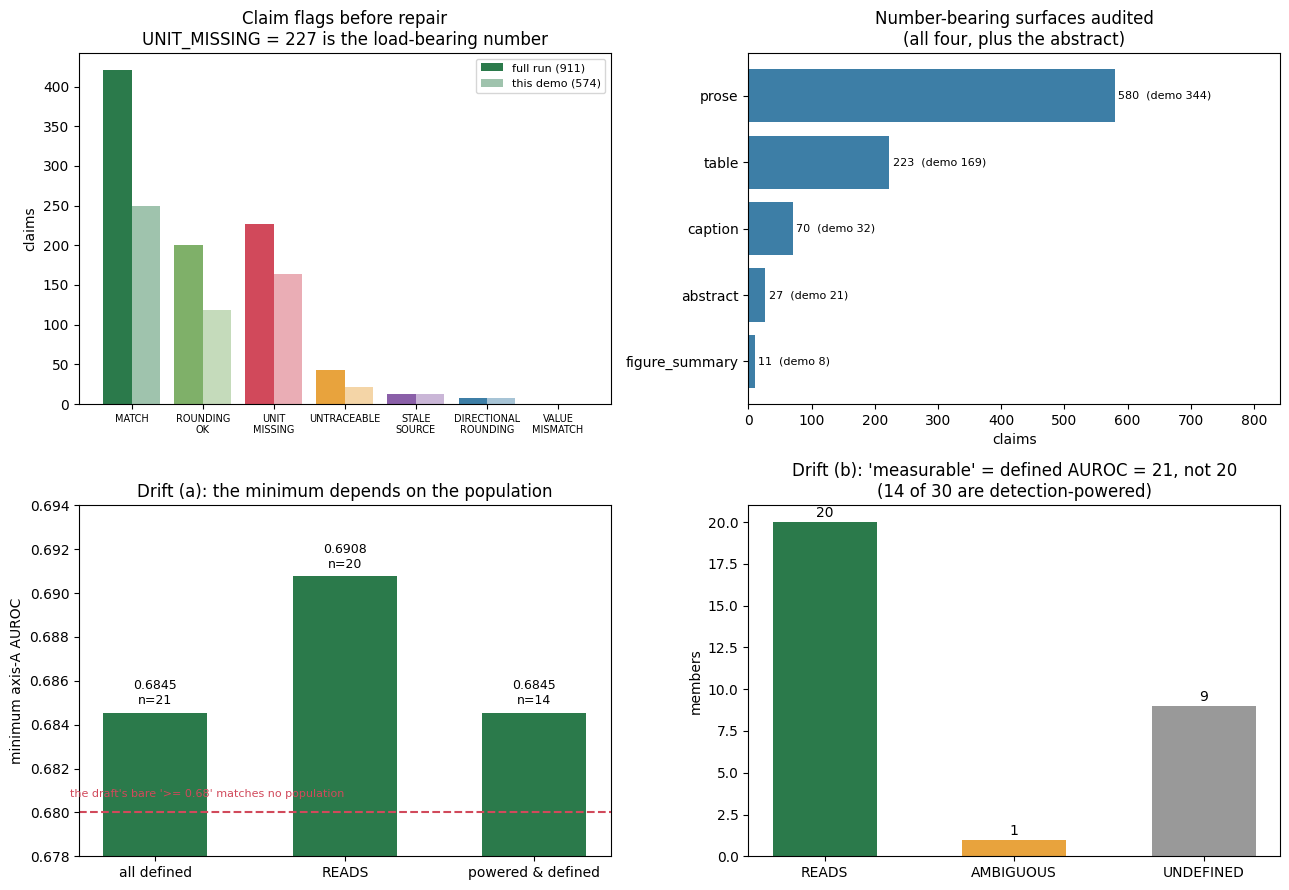

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# (1) flag histogram, full run vs this demo
ax = axes[0, 0]
x = range(len(FLAG_ORDER))
w = 0.4
ax.bar([i - w / 2 for i in x], [full_hist.get(f, 0) for f in FLAG_ORDER], w,
       color=[COLORS[f] for f in FLAG_ORDER], label="full run (911)")
ax.bar([i + w / 2 for i in x], [demo_hist.get(f, 0) for f in FLAG_ORDER], w,
       color=[COLORS[f] for f in FLAG_ORDER], alpha=0.45,
       label=f"this demo ({len(ledger)})")
ax.set_xticks(list(x))
ax.set_xticklabels([f.replace("_", "\n") for f in FLAG_ORDER], fontsize=7)
ax.set_ylabel("claims")
ax.set_title("Claim flags before repair\nUNIT_MISSING = 227 is the load-bearing number")
ax.legend(fontsize=8)

# (2) claims per surface (full run)
ax = axes[0, 1]
surf = data["archived_headline"]["per_surface_breakdown"]
demo_surf = Counter(r["surface"] for r in ledger)
keys = sorted(surf, key=lambda k: -surf[k])
ax.barh([k for k in keys][::-1], [surf[k] for k in keys][::-1], color="#3d7ea6")
for i, k in enumerate(keys[::-1]):
    ax.text(surf[k] + 5, i, f"{surf[k]}  (demo {demo_surf.get(k, 0)})",
            va="center", fontsize=8)
ax.set_xlabel("claims")
ax.set_xlim(0, max(surf.values()) * 1.45)
ax.set_title("Number-bearing surfaces audited\n(all four, plus the abstract)")

# (3) drift (a): the three AUROC populations
ax = axes[1, 0]
pops = [("all defined", "min_auroc_all_defined"), ("READS", "min_auroc_reads"),
        ("powered & defined", "min_auroc_powered")]
vals = [drifts["drift_a_auroc_minimum"][k]["minimum"] for _, k in pops]
ns = [drifts["drift_a_auroc_minimum"][k]["n"] for _, k in pops]
bars = ax.bar([p for p, _ in pops], vals, color="#2b7a4b", width=0.55)
for b_, v, n in zip(bars, vals, ns):
    ax.text(b_.get_x() + b_.get_width() / 2, v + 0.0004, f"{v:.4f}\nn={n}",
            ha="center", fontsize=9)
ax.axhline(0.68, color="#d1495b", ls="--", lw=1.5)
ax.text(-0.45, 0.6807, "the draft's bare '>= 0.68' matches no population",
        color="#d1495b", fontsize=8, ha="left")
ax.set_ylim(0.678, 0.694)
ax.set_ylabel("minimum axis-A AUROC")
ax.set_title("Drift (a): the minimum depends on the population")

# (4) drift (b): the panel tally
ax = axes[1, 1]
tally = drifts["drift_b_measurable_count"]["verdict_tally"]
labels = [k for k in ("READS", "AMBIGUOUS", "UNDEFINED", "AT_CHANCE") if tally.get(k)]
ax.bar(labels, [tally[k] for k in labels],
       color=["#2b7a4b", "#e8a33d", "#999999", "#d1495b"][:len(labels)], width=0.55)
for i, k in enumerate(labels):
    ax.text(i, tally[k] + 0.3, str(tally[k]), ha="center", fontsize=10)
meas = drifts["drift_b_measurable_count"]["n_measurable_defined_auroc"]
ax.set_title(f"Drift (b): 'measurable' = defined AUROC = {meas}, not "
             f"{tally['READS']}\n({drifts['drift_b_measurable_count']['n_powered']} of "
             f"{drifts['drift_b_measurable_count']['n_members']} are detection-powered)")
ax.set_ylabel("members")

plt.tight_layout()
plt.show()

In [23]:
# A slice of the ledger itself: the rows where the sentence resolves but never
# names its aggregation unit. This is the defect the artifact is built to find.
unit_missing = [r for r in ledger if r["flag"] == "UNIT_MISSING"]
print(f"{len(unit_missing)} UNIT_MISSING rows in the demo subset "
      f"(227 over the full draft). First 8:")
print()
for r in unit_missing[:8]:
    print(f"  {r['claim_id']}  {r['token']:<10} {r['statistic_type']:<12} "
          f"-> {r['source_alias']}{r['json_pointer']}")
    print(f"      {r['sentence'][:150]}...")
    print()

print("=" * 90)
print("VERDICT:", data["meta"]["verdict"])
m = data["archived_headline"]["metrics_agg"]
for k in ("n_claims", "n_surfaces", "n_inputs_stamped", "n_pointer_index_total",
          "n_pointer_index_reportable", "frac_claims_resolved", "n_logged_exceptions",
          "n_post_render_claims", "n_post_render_flags", "runtime_seconds", "cost_usd"):
    print(f"  {k:<28} {m[k]}")

164 UNIT_MISSING rows in the demo subset (227 over the full draft). First 8:

  C0050  0.135      p_value      -> V2/metadata/net_and_correction/per_member/instruct_1p7/own_peak_rate/diff_A_minus_B/ci_halfwidth
      The $1/5040$ permutation floor that pinned the original result is genuinely retired ($p = 0.135$ against a floor of $5\times10^{-6}$)....

  C0051  5\times10^{-6} p_value      -> E1/metadata/results/verdict/rule_inputs/permutation_floor
      The $1/5040$ permutation floor that pinned the original result is genuinely retired ($p = 0.135$ against a floor of $5\times10^{-6}$)....

  C0058  -0.071     AUROC        -> E2/metadata/results/joint_scatter_points/20/neg_log10_c50
      Mehta [44] is the closest published neighbour to what our previous draft claimed, and it is a mirror image: one direction on hidden states detects ali...

  C0059  +0.181     AUROC        -> E2/metadata/results/h1_abliterated_arm/per_member/6/paired_A_minus_B/ci95/0
      Mehta [44] is the closest pu